In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import time
import os
#Parameters for latex rendering
plt.rcParams['text.latex.preamble'] = r'\usepackage{{amsmath}}'  # Add any additional packages you may need
plt.rcParams['text.usetex'] = True

##### Function definitions

In [3]:
#General functions
def make_dir(directory_path):
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)

def save_X_csv(input_dir, prefix, data_matrix):
        df = pd.DataFrame(data_matrix)
        df.to_csv(input_dir + f"{prefix}.csv", index=False)
        
def read_X_csv(input_dir, prefix):
    file_path = input_dir + f"{prefix}.csv"
    df = pd.read_csv(file_path)
    return df.values  

##########################################################################

#Postprocess functions

##########################################################################


def subs_mean(X):
# subtract the temporal mean of the data set
    X_mean = np.mean(X, axis=1, keepdims=True)
    # Subtract X_mean from X using vectorized operation
    X -= X_mean
    return X, X_mean

def plot_spectrum(s):
# Plot singular value spectrum and normalized cumulative energy
# Input:
# s - vector containing the singular values
    sigma = s
    sigma_energy = np.cumsum(s)
    # plot singular values and the cumulative energy
    f,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(10, 6), dpi=80)
    #plot only up to the first 100 singular values
    ax1.plot(sigma[0:99],'ko',markersize=3)
    ax1.set_xlabel(r'$\text{Modos}$')
    ax1.set_ylabel(r'$\text{Valores singulares}$')
    ax1.set_title(r'$\text{PCA}$')

    ax2.plot(sigma[0:99], 'ko', markersize=3)
    ax2.semilogy()
    ax2.set_xlabel(r'$\text{Modos}$')
    ax2.set_ylabel(r'$\text{Valores singulares}$')
    ax2.set_title(r'$\text{PCA, semi log-plot}$')

    ax3.plot(sigma_energy / np.sum(sigma), 'ko', markersize=3)
    ax3.set_xlabel(r'$\text{Modos}$')
    ax3.set_ylabel(r'$\text{Energía acumulada}$')
    ax3.set_title(r'$\text{Energía acumulada normalizada}$')
    f.tight_layout()
    f.savefig('PCA_spectrum.png',dpi = 300)
##########################################################################   
        

   
##########################################################################

def inverse_transf(u,s,vh,r_max,r_step, X, X_mean):
# Perform inverse transform and map from the embedded space to the original space
# Calculate reconstruction error
# Input:
# u, s, vh - outputs of the SVD algorithm
# r_max, r_step - max number of modes to keep andmode number increment for calculating the reconstruction error
# Output:
# X_reconstruced - reconstructed data with r_max modes
# err_rec - vector containing the reconstruction error for 1 to r_max modes
    X = X + X_mean
    err_rec = np.zeros(len(range(1,r_max+1,r_step)))
    i = 0
    for r in range(1,r_max+1,r_step):
        S_r = np.diag(s[0:r])
        U_r = u[:,0:r]
        Vh_r = vh[0:r,:]
        X_reconstructed = np.matmul(U_r, S_r)
        X_reconstructed = np.matmul(X_reconstructed, Vh_r)
        X_reconstructed = X_reconstructed + X_mean
        err_rec[i] = np.linalg.norm(X-X_reconstructed)/np.linalg.norm(X)
        i += 1
    return X_reconstructed, err_rec

##########################################################################
def plot_save_reconst(err_rec,  plotToScreen, r_max, r_step):
# Plot the reconstruction error as a function of the number of modes used
# Input:
# err_rec - vector containing the reconstruction error for 1 to r_max modes
# X - original data matrix
# X_reconstructed - reconstructed data matrix with r_max modes
# plotToScreen - if True: show the reconstruction plot on the display
# r_max - max number of modes used for reconstruction
# r_step - mode number increment for calculating the reconstruction error
    plt.figure()
    # plt.ylim(0.005, 1)    
    plt.grid(True, which='both')        
    plt.plot(range(1,r_max+1,r_step),err_rec,linestyle='--', marker='o')
    plt.xlabel('Modes used for reconstruction')
    plt.ylabel('Relative reconstruction error')
    plt.title('PCA reconstruction error')
    plt.semilogy()
    plt.tight_layout()
    plt.savefig('PCA_sdv_rec_error.png',dpi = 200)
    if(plotToScreen):
        plt.show()
    return
##########################################################################

def save_modes(u, outfile_dir, modes, nx, ny):
# Save the spatial modes to a csv file for visualization
# Input:
# u - matrix containing the eigenvectors
# outfile_dir - directory to save the modes
# modes - number of modes to save
# nx, ny - number of grid points in x and y direction    make_dir(outfile_dir)
    for i in range(modes):
        U_i = u[:, i]
        print("shape de U_i  ", U_i.shape)
        U_i = (U_i - U_i.min()) / (U_i.max() - U_i.min())
        U_i = U_i.reshape((ny, nx))
        save_X_csv(outfile_dir, f"mode_{i+1}", U_i)
        
        colors = [(0, 'cyan'), (0.40, 'blue'), (0.5, 'black'), (0.60, 'red'), (1, 'yellow')]
        custom_cmap = LinearSegmentedColormap.from_list('custom_colormap', colors)

        plt.imshow(U_i, cmap=custom_cmap)
        plt.axis('off')
        plt.xticks([]) 
        plt.yticks([])     
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.savefig(outfile_dir+f"mode_{i+1}.png", dpi=300)
        
        # clean fig before next iteration
        plt.clf()
        # if want to plot all modes together
        # row = i // 4
        # col = i % 4

        # axes[row, col].imshow(U_i, cmap=custom_cmap)
        # axes[row, col].set_title(str(i+1))
        # axes[row, col].axis('off') 
        # axes[row, col].set_xticks([])  
        # axes[row, col].set_yticks([])  

    # plt.tight_layout()
    # plt.savefig('modes/PCA_modes_combined.png', dpi=300)

#### Parameters

In [4]:
#Grid points in x and y direction
nx, ny =  351, 160
#Data directory
input_dir = '../modV/'
#Max number of components and step for postprocess
r_max = 12
r_step = 1

#### Read velocity

In [5]:

#PCA usual notation from here
# X - velocity module
X = read_X_csv(input_dir, 'modV_crop')


n ,m = X.shape
print("Data matrix X is n by m:", n, "x", m, flush = True)

Data matrix X is n by m: 56160 x 1000


#### Perform PCA

In [6]:
#First, center data
X, X_mean = subs_mean(X)
start = time.time()
u, s, vh = np.linalg.svd(X, full_matrices = False)
end = time.time()
print('Time elapsed for PCA:',end - start, ' s')

Time elapsed for PCA: 2.6116738319396973  s


### Post-process

##### Singular value spectrum and normalized cumulative energy

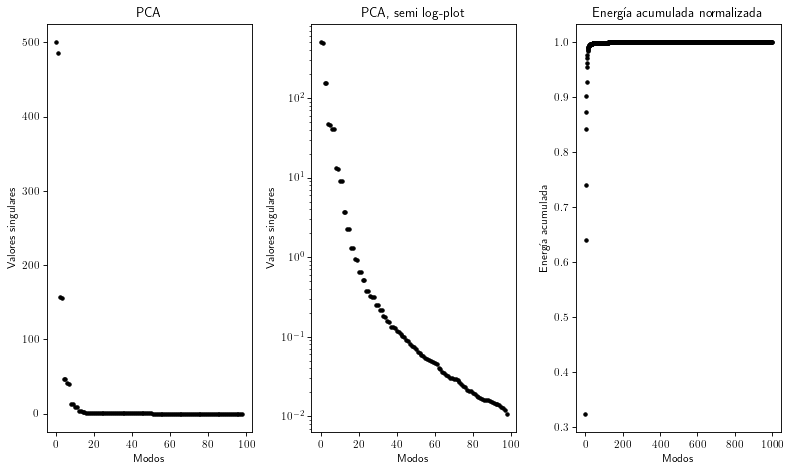

In [7]:
plot_spectrum(s)

#### Save and plot PCA modes

In [10]:
#save modes in csv and png files
out_dir = 'modes/'
modesToSave = 8

save_modes(u, out_dir, modesToSave, nx, ny)

shape de U_i   (56160,)
shape de U_i   (56160,)
shape de U_i   (56160,)
shape de U_i   (56160,)
shape de U_i   (56160,)
shape de U_i   (56160,)
shape de U_i   (56160,)
shape de U_i   (56160,)


<Figure size 640x480 with 0 Axes>

##### Data reconstruction

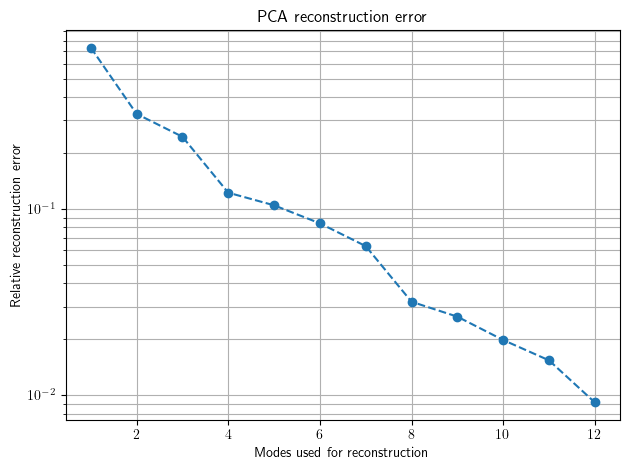

In [ ]:
X_reconstructed, err_rec = inverse_transf(u, s, vh, r_max, r_step, X, X_mean)
# Save reconstruction errors for further post-processing
err_rec_mat = np.stack((range(1,r_max+1,1) ,err_rec),axis = -1)
np.savetxt("error_rec.csv", err_rec_mat, delimiter=",")
plotToScreen = True

plot_save_reconst(err_rec, plotToScreen, r_max, r_step)